# NAO example notebook

This notebook contains an example of access of a dataset and ERA5 data and evaluation of the NAO teleconnection (station based index) and plot with the diagnostics part of the teleconnections module.

The only import needed is the NAO and PlotNAO classes from the `aqua.diagnostics.teleconnections` module

In [1]:
from aqua.diagnostics.teleconnections import NAO, PlotNAO

%matplotlib inline

# Evaluating the NAO

To simplify the code below we set the two dataset we want to analyse as dictionary here. The syntax is the same as for the `Reader`.
The initialization requires a minimal set of arguments. All other details can be set while calling the individual methods.

Notice that an instance of the class is required for each dataset.

In [2]:
nao_dataset = NAO(
    catalog="climatedt-gen2", model="IFS-NEMO-5km", exp="baseline-hist", source="lra-r100-monthly", loglevel="INFO"
)
nao_obs = NAO(catalog="obs", model="ERA5", exp="era5", source="monthly", loglevel="INFO")

We first retrieve the data. The needed variable is deduced by the class and it can be modified with YAML file (see `/config/diagnostics/teleconnections/definitions/`)

In [3]:
nao_dataset.retrieve()
nao_obs.retrieve()

/home/b/b383197/miniforge3/envs/aqua-dev/lib/python3.14/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/home/b/b383197/miniforge3/envs/aqua-dev/lib/python3.14/site-packages/intake/catalog/utils.py:182: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
2026-07-24 14:33:23 :: ConfigPath :: INFO     -> IFS-NEMO-5km_baseline-hist_lra-r100-monthly triplet found in in climatedt-gen2!
2026-07-24 14:33:23 :: Reader :: WARNING  -> The machine configured (levante) is different from the machine in the catalog (mn5). Please check that the data you are looking for are on the machine you are working on.
2026-07-24 14:33:23 :: FixerConfigure :: INFO     -> Convention dictionary: eccodes-2.39.0
2026-07-24 14:33:23 :: FixerConfigure :: INFO     -> No fixer_name found, only convention will be applied


The index can be computed with a simple method. A months window different from the default (3 months) can be set. The result is stored in the `index` attribute of the class.

In [4]:
nao_dataset.compute_index()
nao_obs.compute_index()

In [5]:
nao_dataset.save_netcdf(nao_dataset.index, diagnostic="nao", diagnostic_product="index")
nao_obs.save_netcdf(nao_obs.index, diagnostic="nao", diagnostic_product="index")

2026-07-24 14:35:46 :: create_folder :: INFO     -> Folder ./netcdf already exists
2026-07-24 14:35:46 :: OutputSaver :: INFO     -> Saved NetCDF: ./netcdf/nao.index.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.nc
2026-07-24 14:35:46 :: create_folder :: INFO     -> Folder ./netcdf already exists
2026-07-24 14:35:46 :: OutputSaver :: INFO     -> Saved NetCDF: ./netcdf/nao.index.obs.ERA5.era5.r1.nc


We then evaluate regression and correlation. By default this is done for the entire dataset, but a season can be selected with the `season` argument.
By default the statistics is computed with the same variable as the index, but the `var` argument can be used to ask for another variable.

In [6]:
reg_dataset = nao_dataset.compute_regression(season="DJF")
reg_obs = nao_obs.compute_regression(season="DJF")

In [7]:
cor_dataset = nao_dataset.compute_correlation(season="DJF")
cor_obs = nao_obs.compute_correlation(season="DJF")

Also for these plot we can save the netcdf.

NB: The season will be working when using the new version of the outputnamer class.

In [8]:
nao_dataset.save_netcdf(reg_dataset, diagnostic="nao", diagnostic_product="regression.DJF")
nao_obs.save_netcdf(reg_obs, diagnostic="nao", diagnostic_product="regression.DJF")

2026-07-24 14:35:46 :: create_folder :: INFO     -> Folder ./netcdf already exists
2026-07-24 14:35:46 :: OutputSaver :: INFO     -> Saved NetCDF: ./netcdf/nao.regression.djf.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.nc
2026-07-24 14:35:46 :: create_folder :: INFO     -> Folder ./netcdf already exists
2026-07-24 14:36:20 :: OutputSaver :: INFO     -> Saved NetCDF: ./netcdf/nao.regression.djf.obs.ERA5.era5.r1.nc


In [9]:
nao_dataset.save_netcdf(cor_dataset, diagnostic="nao", diagnostic_product="correlation.DJF")
nao_obs.save_netcdf(cor_obs, diagnostic="nao", diagnostic_product="correlation.DJF")

2026-07-24 14:36:20 :: create_folder :: INFO     -> Folder ./netcdf already exists


2026-07-24 14:36:20 :: OutputSaver :: INFO     -> Saved NetCDF: ./netcdf/nao.correlation.djf.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.nc
2026-07-24 14:36:20 :: create_folder :: INFO     -> Folder ./netcdf already exists
2026-07-24 14:37:11 :: OutputSaver :: INFO     -> Saved NetCDF: ./netcdf/nao.correlation.djf.obs.ERA5.era5.r1.nc


# Plot the NAO

The `PlotNAO` class will take care of plotting the result of multiple dataset. It will be initialized with just the indexes, specifying what is a dataset and what is the reference to compare against.

The class accept any xarray, but it will use attributes to create labels and other details. It may be needed the creation of new attributes if you want to use results that do not come from AQUA with this plot class.

In [10]:
plot = PlotNAO(loglevel="INFO", indexes=nao_dataset.index, ref_indexes=nao_obs.index)

The index plot is done with the `plot_index` method. Multiple panels are generated if multiple dataset are provided.

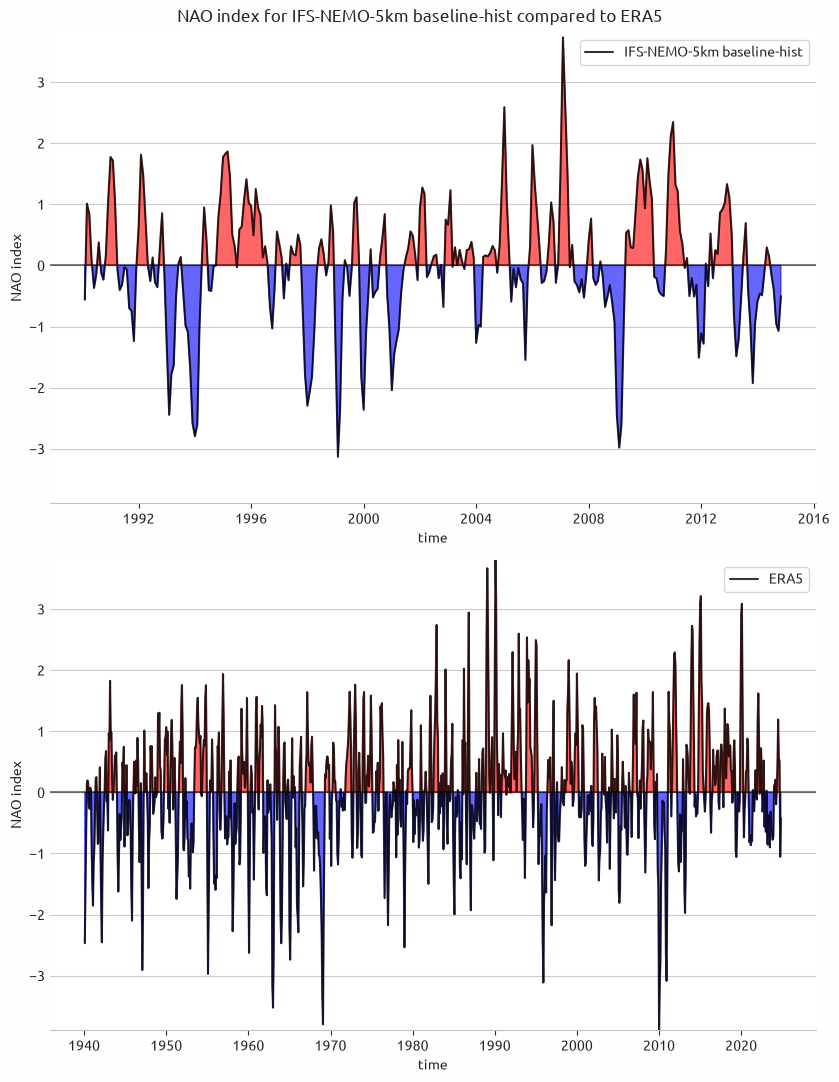

In [11]:
fig_index, _ = plot.plot_index()

We create the caption to be embedded with the metadata of the figure. We save the image as png but pdf is supported as well.

In [12]:
description = plot.set_index_description()
plot.save_plot(fig_index, diagnostic_product="index", metadata={"description": description})

2026-07-24 14:37:11 :: create_folder :: INFO     -> Folder ./png already exists
2026-07-24 14:37:12 :: OutputSaver :: INFO     -> Saved PNG: ./png/nao.index.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.obs.ERA5.era5.png
2026-07-24 14:37:12 :: create_folder :: INFO     -> Folder ./pdf already exists
2026-07-24 14:37:13 :: OutputSaver :: INFO     -> Saved PDF: ./pdf/nao.index.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.obs.ERA5.era5.pdf
2026-07-24 14:37:13 :: create_folder :: INFO     -> Folder ./svg already exists
2026-07-24 14:37:13 :: OutputSaver :: INFO     -> Saved SVG: ./svg/nao.index.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.obs.ERA5.era5.svg


We strongly suggest to load the regression and correlation datasets before giving them to the plot routines, since cartopy and dask do not perform very well together.

In [13]:
reg_dataset.load()
reg_obs.load()

<xarray.DataArray (lat: 721, lon: 1440)> Size: 8MB
array([[ -45.94003234,  -45.94003234,  -45.94003234, ...,  -45.94003234,
         -45.94003234,  -45.94003234],
       [ -45.90756846,  -45.90292011,  -45.89954918, ...,  -45.91830223,
         -45.91334163,  -45.91331679],
       [ -45.8668582 ,  -45.86307565,  -45.85492863, ...,  -45.88359933,
         -45.87866357,  -45.8734262 ],
       ...,
       [-226.53300429, -226.53202494, -226.52983915, ..., -226.53517588,
        -226.53601329, -226.53453717],
       [-225.07393552, -225.07264392, -225.07092652, ..., -225.07267231,
        -225.07234586, -225.07216135],
       [-223.93768177, -223.93768177, -223.93768177, ..., -223.93768177,
        -223.93768177, -223.93768177]], shape=(721, 1440))
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Attributes: (12/26)
    standard_name:       air_pressure_at_mean_sea_level
    units:               Pa
    code:                151
    table:               128
    history:             \n2026-07-24 14:34:31 AQUA💧: Variable renamed msl fr...
    paramId:             151
    ...                  ...
    exp:                 era5
    realization:         r1
    timestamp:           2026-07-24 14:35:46
    aqua_version:        1.0.0a6
    AQUA_season:         DJF
    long_name:           Linear regression of mean sea level pressure with NA...

Here we show an example of plot flow. The first method will create the figure and it will be enough for the notebook usage.
However a description to be stored as metadata and a saving routine are available and shown in the following example.

2026-07-24 14:37:14 :: PlotNAO :: INFO     -> Map description: Linear regression of mean sea level pressure with NAO index for IFS-NEMO-5km baseline-hist (from 1990-01 to 2014-12) (DJF) compared to ERA5 (from 1940-01 to 2024-12). Contours represent the model regression, while shading is the difference between the model and the reference.
2026-07-24 14:37:14 :: create_folder :: INFO     -> Folder ./png already exists
2026-07-24 14:37:15 :: OutputSaver :: INFO     -> Saved PNG: ./png/nao.regression.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.obs.ERA5.era5.png
2026-07-24 14:37:15 :: create_folder :: INFO     -> Folder ./pdf already exists
2026-07-24 14:37:15 :: OutputSaver :: INFO     -> Saved PDF: ./pdf/nao.regression.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.obs.ERA5.era5.pdf
2026-07-24 14:37:15 :: create_folder :: INFO     -> Folder ./svg already exists
2026-07-24 14:37:15 :: OutputSaver :: INFO     -> Saved SVG: ./svg/nao.regression.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.obs

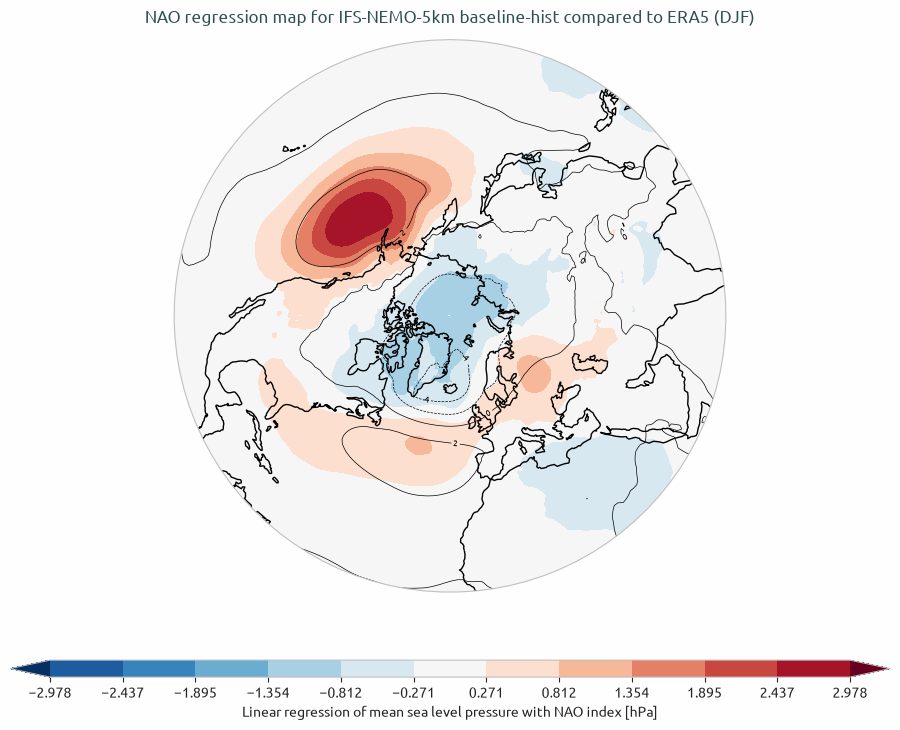

In [14]:
fig_reg = plot.plot_maps(maps=reg_dataset, ref_maps=reg_obs, statistic="regression")
description = plot.set_map_description(maps=reg_dataset, ref_maps=reg_obs, statistic="regression")
plot.save_plot(fig_reg, diagnostic_product="regression", metadata={"description": description})

In [15]:
cor_dataset.load()
cor_obs.load()

<xarray.DataArray (lat: 721, lon: 1440)> Size: 4MB
array([[-0.12882417, -0.12882417, -0.12882417, ..., -0.12882417,
        -0.12882417, -0.12882417],
       [-0.12959488, -0.12958589, -0.1295816 , ..., -0.12961285,
        -0.12960269, -0.1296062 ],
       [-0.1294473 , -0.129439  , -0.12942412, ..., -0.1294815 ,
        -0.1294742 , -0.12946366],
       ...,
       [-0.45387253, -0.45384943, -0.4538238 , ..., -0.45395052,
        -0.45392698, -0.45390114],
       [-0.44989294, -0.4498802 , -0.44986573, ..., -0.4499269 ,
        -0.44991213, -0.44990063],
       [-0.445809  , -0.445809  , -0.445809  , ..., -0.445809  ,
        -0.445809  , -0.445809  ]], shape=(721, 1440), dtype=float32)
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Attributes: (12/26)
    standard_name:       air_pressure_at_mean_sea_level
    units:               1
    code:                151
    table:               128
    history:             \n2026-07-24 14:34:31 AQUA💧: Variable renamed msl fr...
    paramId:             151
    ...                  ...
    exp:                 era5
    realization:         r1
    timestamp:           2026-07-24 14:36:20
    aqua_version:        1.0.0a6
    AQUA_season:         DJF
    long_name:           Correlation of mean sea level pressure with NAO index

2026-07-24 14:37:17 :: PlotNAO :: INFO     -> Map description: Correlation of mean sea level pressure with NAO index for IFS-NEMO-5km baseline-hist (from 1990-01 to 2014-12) (DJF) compared to ERA5 (from 1940-01 to 2024-12). Contours represent the model correlation, while shading is the difference between the model and the reference.
2026-07-24 14:37:17 :: create_folder :: INFO     -> Folder ./png already exists
2026-07-24 14:37:18 :: OutputSaver :: INFO     -> Saved PNG: ./png/nao.correlation.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.obs.ERA5.era5.png
2026-07-24 14:37:18 :: create_folder :: INFO     -> Folder ./pdf already exists
2026-07-24 14:37:18 :: OutputSaver :: INFO     -> Saved PDF: ./pdf/nao.correlation.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.obs.ERA5.era5.pdf
2026-07-24 14:37:18 :: create_folder :: INFO     -> Folder ./svg already exists
2026-07-24 14:37:18 :: OutputSaver :: INFO     -> Saved SVG: ./svg/nao.correlation.climatedt-gen2.IFS-NEMO-5km.baseline-hist.r1.obs.E

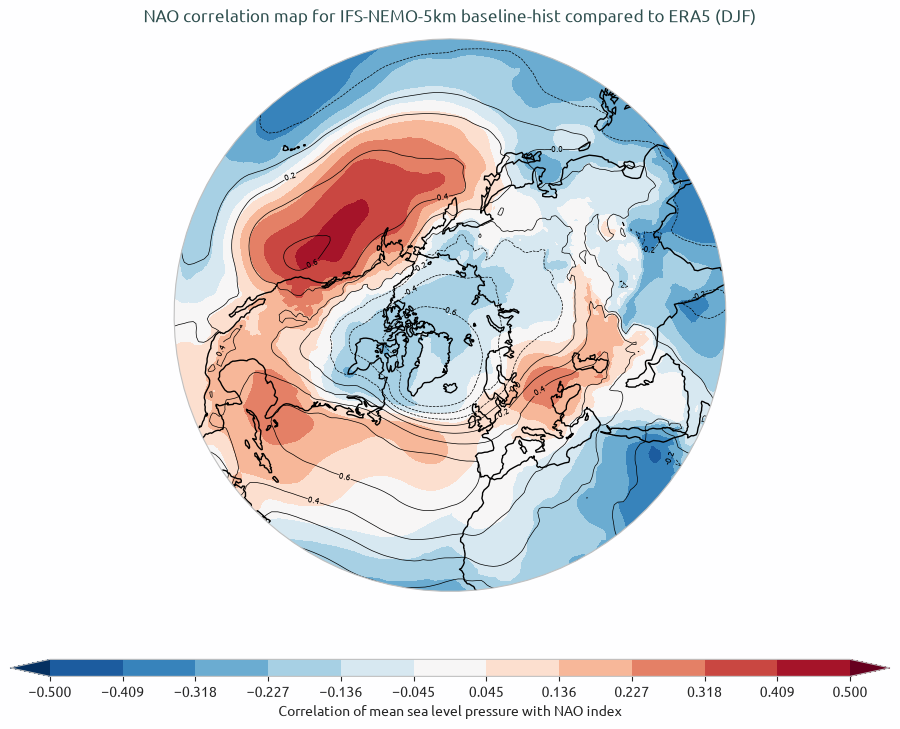

In [16]:
fig_cor = plot.plot_maps(maps=cor_dataset, ref_maps=cor_obs, statistic="correlation")
description = plot.set_map_description(maps=cor_dataset, ref_maps=cor_obs, statistic="correlation")
plot.save_plot(fig_cor, diagnostic_product="correlation", metadata={"description": description})

# NCAR comparison

With the NAO index computed, we can compare with observational data from NCAR, to check if the index is computed correctly. NCAR data are available in the data folder available in this same folder.

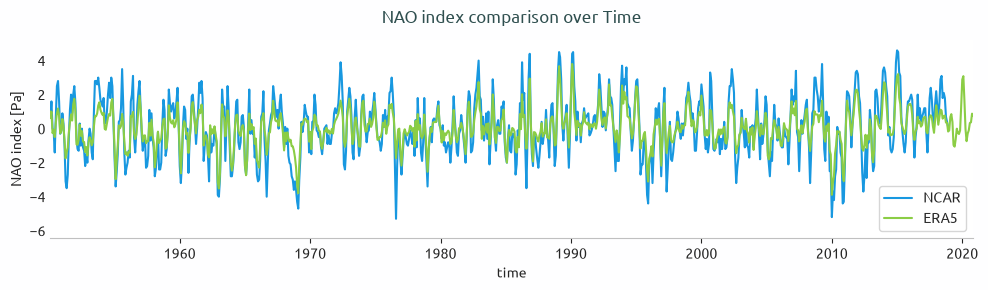

In [17]:
import datetime

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

ncar_path = "data/nao_station_seasonal.txt"
nao_ncar = np.genfromtxt(ncar_path, skip_header=3, skip_footer=4)

year = nao_ncar[:, 0]
month_data = nao_ncar[:, 1:]
time = xr.cftime_range(start=str(int(year[0])), periods=12 * len(year), freq="MS", calendar="standard")
month_data = month_data.reshape(-1)
nao_ncar = xr.DataArray(month_data, coords=[time], dims=["time"], name="monthly_data")

time_vals = np.array(time.values)

# Convert to datetime objects
datetimes = [np.datetime64(t).astype(datetime.datetime) for t in time_vals]

# Plot with matplotlib
fig = plt.figure(figsize=(10, 3))
plt.plot(datetimes, nao_ncar.values, label="NCAR")

plt.xlim(datetime.datetime(1950, 1, 31, 0, 0), datetime.datetime(2020, 10, 31, 0, 0))

nao_obs.index.plot(label="ERA5")
plt.legend()
plt.title("NAO index comparison over Time")
fig.tight_layout()

plt.show()